<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW3_Classification_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 3. Линейная классификация (base)**

### **Оценивание и штрафы**

С наступающим новым годом, друзья! Магистратура бежит быстро и мы бежим очень быстро, а зима — то время, когда хотелось бы бежать чуть медленнее. Поэтому это домашнее задание мы сделали сильно короче от его начальной версии!

Как всегда, каждая из задач имеет «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

В задании две части:

- Часть 1: написание логистической регрессии своими руками — уверенны, логлосс вы уже знаете как свои пять пальцев.
- Часть 2: решение задачи классификации на текстах.

In [58]:
%pylab inline
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import numpy as np
from matplotlib import pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer


from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

Populating the interactive namespace from numpy and matplotlib


In [3]:
from google.colab import drive # Если вы работаете в коллабе
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Часть 1. Логистическая регрессия своими руками (5 баллов)**

Логистическая регрессия — безумно важная и удобная модель для понимания начальных концепций. Вы много практиковались с выведением формулы градиента логлосса, шага спуска, а в прошлом дз сделали SGD. Давайте сделаем ещё шаг вперед — и реализуем логистическую регрессию своими руками.

На практике, часто хватает алгоритмов из коробки. Но иногда очень удобно сделать свой алгоритм.

## **Теоретическая сноска: почему LogLoss'а так много**

Почти наверное (в математике это значит, во всех случаях, кроме множества размером 0) логлосс набил оскомину за несколько заданий. Давайте посмотрим на него ещё раз:

В логистической регрессии функция потерь

$$\text{LogLoss}(y, \hat{p}) = -\left(y\log \hat{p} + (1-y)\log (1-\hat{p})\right)$$

Зачем мы так долго с ней возимся?

#### **Пункт 1.**
Во-первых, это **следствие максимизации правдоподобия** при биномиальной модели.

Если считать, что целевая переменная (Y\in{0,1}) распределена как

$$P(Y=1 \mid x) = \hat{p}(x), \qquad P(Y=0\mid x) = 1-\hat{p}(x),$$
то правдоподобие выборки ( (x_i, y_i) )\ равно
$$L = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}.$$

Максимизация $\log L$ эквивалентна минимизации LogLoss.
Таким образом, LogLoss — **единственная функция потерь, полностью согласованная с вероятностной моделью логистической регрессии**.

#### **Пункт 2.**

Во-вторых, логлосс поможет нам в будущем понять другие функции потерь. Так, например LogLoss является частным случаем **кросс-энтропии между истинным распределением и предсказанным**.

Для двух распределений $p$ (истинного) и $q$ (предсказанного) кросс-энтропия определяется как

$$H(p,q) = -\sum_{k} p(k)\log q(k).$$

В бинарном случае истинное распределение дискретно:

$$p = (y, 1-y), \qquad q = (\hat{p}, 1-\hat{p}),$$
и подстановка даёт

$$H(p,q) = -\left[y\log \hat{p} + (1-y)\log (1-\hat{p})\right] = \text{LogLoss}.$$


В общем, любим, жалуем и реализуем.




### **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1.5 балла). Градиентного спуска**

**Задание 1.2 (1.5 балла). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [4]:
class LogReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2):
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d + 1) — init weights
        eta: learning rate
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = []
        if self.gd_type not in ['full', 'stochastic']:
            raise ValueError("gd_type must be 'full' or 'stochastic'")

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """

        if self.w0 is None:
            self.w = np.random.rand(X.shape[1] + 1)
        else:
            self.w = self.w0.copy()

        self.loss_history = []
        self.loss_history.append(self.calc_loss(X, y))

        for _ in range(self.max_iter):
            w_old = self.w.copy()
            grad_w = self.calc_gradient(X, y)
            self.w -= self.eta * grad_w
            self.loss_history.append(self.calc_loss(X, y))

            if np.linalg.norm(w_old - self.w) < self.tolerance:
                break

        return self

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict_proba(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        full_X = np.hstack([np.ones((X.shape[0], 1)), X])

        return self.sigmoid(full_X @ self.w)


    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
        
        probs = self.predict_proba(X)
        return (probs > 0.5).astype(int)


    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """

        full_X = np.hstack([np.ones((X.shape[0], 1)), X])

        if self.gd_type == 'full':
            p = self.sigmoid(full_X @ self.w)
            return (full_X.T @ (p - y)) / X.shape[0]
        else:
            i = np.random.randint(len(X))
            p = self.sigmoid(full_X[i] @ self.w)
            return (full_X[i] * (p - y[i]))


    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """

        full_X = np.hstack([np.ones((X.shape[0], 1)), X])
        p = np.clip(self.sigmoid(full_X @ self.w), 1e-15, 1 - 1e-15)
        loss = -(y * np.log(p) + (1 - y) * np.log(1 - p))
        return np.mean(loss)

Теперь проверим работу вашего класса на синтетических данных.

In [5]:
X, y = make_classification(
    n_samples=100000, n_features=20, n_informative=2,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)



### **Задание 2 (0.6 балла)**

Теперь давайте тестировать модель.
1. Обучите свою логистическую регрессию на синтетических данных (0.2 балла) — на полном GD и SGD;
2. Cравните результат с моделью из библиотеки. Посчитайте roc-auc, accuracy, постройте ROC и PR кривые. , оцените разницу в производительности моделей по метрикам качества. Ответьте на вопросы:
- Какая показывает лучший результат? Почему?
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

In [6]:
%time
lr_sgd = LogReg(gd_type='stochastic')
lr_sgd.fit(X_train, y_train)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.25 µs


LogReg()

In [7]:
%time
lr_full = LogReg(gd_type='full')
lr_full.fit(X_train, y_train)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 6.2 µs


LogReg(gd_type='full')

In [8]:
%time
lr_skl = LogisticRegression()
lr_skl.fit(X_train, y_train)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 7.15 µs


LogisticRegression()

In [9]:
lr_sgd_pred = lr_sgd.predict(X_test)
lr_full_pred = lr_full.predict(X_test)
lr_skl_pred = lr_skl.predict(X_test)

print(f'stochastic custom\naccuracy: {accuracy_score(y_test, lr_sgd_pred)}, roc_auc: {roc_auc_score(y_test, lr_sgd.predict(X_test))}')
print(f'full custom\naccuracy: {accuracy_score(y_test, lr_full_pred)}, roc_auc: {roc_auc_score(y_test, lr_full.predict(X_test))}')
print(f'sklearn model\naccuracy: {accuracy_score(y_test, lr_skl_pred)}, roc_auc: {roc_auc_score(y_test, lr_skl.predict(X_test))}')


stochastic custom
accuracy: 0.7169333333333333, roc_auc: 0.7168695580660168
full custom
accuracy: 0.8459, roc_auc: 0.8458141995714082
sklearn model
accuracy: 0.8681, roc_auc: 0.8681011072682042


### **Задание 3 (0.4 балла)**

Для трех полученных моделей, визуализируйте прогнозы по данным на тестовой выборке. Для этого:
- получите прогнозы;
- сомжите данные, используя PCA. Не забудьте, что PCA полагает нулевое среднее и единичную дисперсию;
- покрасьте данные по прогнозам.

Как различаются графики для трёх моделей? И различаются ли?

In [10]:
pca = PCA(n_components=2)

X_test_decomp = pca.fit_transform(X_test)

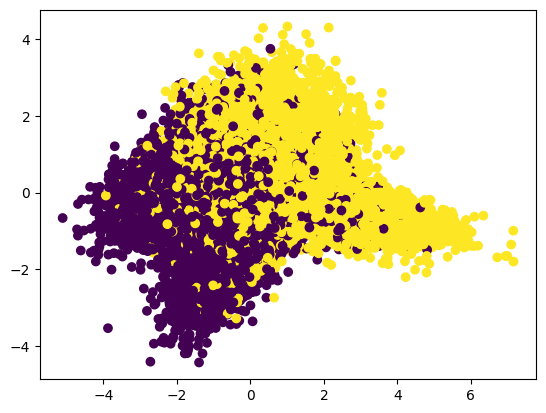

In [11]:
plt.scatter(
    X_test_decomp[:, 0],
    X_test_decomp[:, 1],
    c=lr_sgd_pred
)

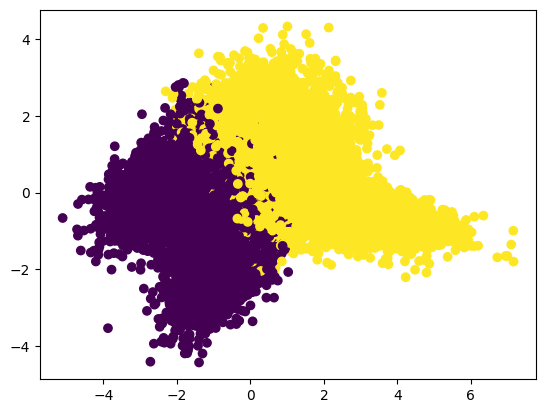

In [12]:
plt.scatter(
    X_test_decomp[:, 0],
    X_test_decomp[:, 1],
    c=lr_full_pred
)

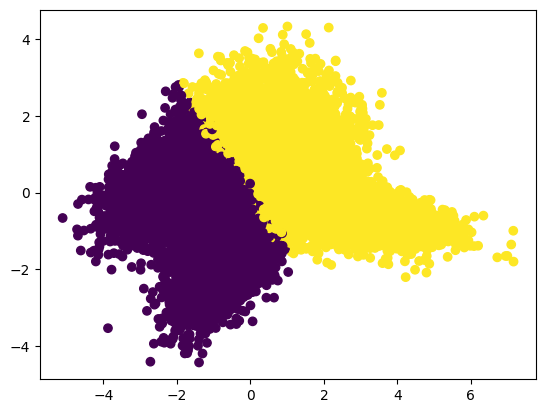

In [13]:
plt.scatter(
    X_test_decomp[:, 0],
    X_test_decomp[:, 1],
    c=lr_skl_pred
)

# **Часть 2. Обучение моделей на текстовых данных. (5 баллов)**

 ### **Подготовка данных из реального мира.**

Ещё одна прелесть простых моделей — возможность решать с ними неструктурированные (изначально не табличные) задачи. Давайте посмотрим на это в действии на примере текстов.


Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [14]:
from sklearn.model_selection import train_test_split

PATH = '/content/drive/MyDrive/train.csv'
data = pd.read_csv(PATH)

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### **Задание 10. Базовая предобработка (1.5 балла).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой (0.2 балла).

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


- Проанализируйте количество уникальных значений в столбцах, опустив `text`. Сделайте выводы. (0.5 балла)

In [16]:
data['keyword'] = data['keyword'].fillna('')
data['location'] = data['location'].fillna('')

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7613 non-null   object
 2   location  7613 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


- Проанализируйте соотношение классов в целевой переменной. Какое оно? Выберите метрику, с помощью которой будете оценивать модель.  (0.5 балла)

In [18]:
data['target'].value_counts()

,count
target,
0,4342
1,3271


- Объедините все три текстовых столбца в один для baseline (вам поможет конкатенация строк) (0.3 балла)

In [19]:
data_new = pd.DataFrame()
data_new['text'] = (data['keyword'].astype(str) + ' ' + data['location'].astype(str) + ' ' + data['text'].astype(str))

- Наконец, поделите данные на тренировочную и тестовую выборки. (0.2 балла)

In [20]:
X = data_new['text']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества и насколько разнообразны данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица? (0.3 балла)

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_train = pd.DataFrame(
    cv.fit_transform(X_train).toarray(),
    columns=cv.get_feature_names_out()
)

X_test = pd.DataFrame(
    cv.transform(X_test).toarray(),
    columns=cv.get_feature_names_out()
)

- Обучите логистическую регрессию на полученном наборе. Модель возьмите из библиотеки. Какое качество по выбранной вами метрике у модели получилось на тестовых данных? (0.3 балла)

In [22]:
%time
lr = LogisticRegression()

lr.fit(X_train, y_train)
pred = lr.predict(X_test)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 6.91 µs


In [23]:
f1_score(y_test, pred)

0.7529665587918015

- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.(0.4 балла)

In [24]:
%time
svc = SVC()

svc.fit(X_train, y_train)
pred_svc = svc.predict(X_test)

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 6.68 µs


In [25]:
f1_score(y_test, pred_svc)

0.7430875576036866

### **Задание 12. Улучшение базовых моделей за счет данных. (0.3 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют.

Обучайте и логистическую регрессию, и SVC.

In [ ]:
cv = CountVectorizer()

print(X_train.shape)

(5329, 18455)


In [33]:
X = data_new['text']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [34]:
vectorizer_params = [
    {"max_features": 800, "min_df": 2, "max_df": 0.95, "ngram_range": (1, 1)},
    {"max_features": 1100, "min_df": 2, "max_df": 0.95, "ngram_range": (1, 1)},
    {"max_features": 1300, "min_df": 3, "max_df": 0.9, "ngram_range": (1, 1)},
    {"max_features": 1200, "min_df": 2, "max_df": 0.95, "ngram_range": (1, 2)},
]

In [38]:
for params in vectorizer_params:
    cv = CountVectorizer(**params)

    X_train_vec = cv.fit_transform(X_train)
    X_test_vec = cv.transform(X_test)

    n_objects = X_train_vec.shape[0]
    n_features = X_train_vec.shape[1]

    if n_features > n_objects / 4:
        continue

    model = LogisticRegression()
    model.fit(X_train_vec, y_train)
    pred = model.predict(X_test_vec)
    proba = model.predict_proba(X_test_vec)[:, 1]
    print(
        params,
        "features:", n_features,
        "accuracy:", accuracy_score(y_test, pred),
        "roc_auc:", roc_auc_score(y_test, proba),
        "f1_score", f1_score(y_test, pred)
    )

{'max_features': 800, 'min_df': 2, 'max_df': 0.95, 'ngram_range': (1, 1)} features: 800 accuracy: 0.7902802101576182 roc_auc: 0.8463243448728702 f1_score 0.7417789757412399
{'max_features': 1100, 'min_df': 2, 'max_df': 0.95, 'ngram_range': (1, 1)} features: 1100 accuracy: 0.787215411558669 roc_auc: 0.845168584686629 f1_score 0.7412140575079872
{'max_features': 1300, 'min_df': 3, 'max_df': 0.9, 'ngram_range': (1, 1)} features: 1300 accuracy: 0.781523642732049 roc_auc: 0.8447299220539308 f1_score 0.73471557682084
{'max_features': 1200, 'min_df': 2, 'max_df': 0.95, 'ngram_range': (1, 2)} features: 1200 accuracy: 0.7876532399299475 roc_auc: 0.8466663996204802 f1_score 0.739946380697051


In [40]:
for params in vectorizer_params:
    cv = CountVectorizer(**params)

    X_train_vec = cv.fit_transform(X_train)
    X_test_vec = cv.transform(X_test)

    n_objects = X_train_vec.shape[0]
    n_features = X_train_vec.shape[1]

    if n_features > n_objects / 4:
        continue

    model = SVC(probability=True)
    model.fit(X_train_vec, y_train)

    pred = model.predict(X_test_vec)
    proba = model.predict_proba(X_test_vec)[:, 1]

    print(
        params,
        "features:", n_features,
        "accuracy:", accuracy_score(y_test, pred),
        "roc_auc:", roc_auc_score(y_test, proba),
        "f1_score", f1_score(y_test, pred)
    )

{'max_features': 800, 'min_df': 2, 'max_df': 0.95, 'ngram_range': (1, 1)} features: 800 accuracy: 0.792031523642732 roc_auc: 0.8476741062592484 f1_score 0.728726442033124
{'max_features': 1100, 'min_df': 2, 'max_df': 0.95, 'ngram_range': (1, 1)} features: 1100 accuracy: 0.7902802101576182 roc_auc: 0.8508723770566482 f1_score 0.7261292166952544
{'max_features': 1300, 'min_df': 3, 'max_df': 0.9, 'ngram_range': (1, 1)} features: 1300 accuracy: 0.7937828371278459 roc_auc: 0.8516267825332944 f1_score 0.7316239316239316
{'max_features': 1200, 'min_df': 2, 'max_df': 0.95, 'ngram_range': (1, 2)} features: 1200 accuracy: 0.7924693520140105 roc_auc: 0.8495544255836529 f1_score 0.726643598615917


### **Задание 13. Улучшение базовых моделей за счет данных 2. (0.7 балла).**

В первом пункте мы склеили все строки в одну. Но можно было бы поступить иначе — и получить категории из `'keyword', 'location'`. Протестируйте такой подход на обеих моделях и замерьте качество. Улучшает ли это результат?

In [42]:
X = data.drop(columns=['target', 'id'])
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
preprocessor = ColumnTransformer([
    ('text', CountVectorizer(max_features=1000, min_df=2, max_df=0.95), 'text'),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['keyword', 'location'])
])

lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression())
])

lr_pipe.fit(X_train, y_train)
pred_lr = lr_pipe.predict(X_test)
print(f1_score(y_test, pred_lr))

0.7433242506811989


In [51]:
svc_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', SVC())
])

svc_pipe.fit(X_train, y_train)
pred_svc = svc_pipe.predict(X_test)
print(f1_score(y_test, pred_svc))

0.7367192060712201


### **Задание 13. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [ ]:
params = {'model__C': [0.001, 0.01, 0.1, 1, 5, 10, 100]}

gs = GridSearchCV(lr_pipe, params, cv=5, scoring='r2')
gs.fit(X_train, y_train)
pred_lr = gs.predict(X_test)
print(f1_score(y_test, pred_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.7387592487194081


- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [56]:
params = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf']
}

gs = GridSearchCV(svc_pipe, params, cv=5, scoring='r2')
gs.fit(X_train, y_train)
pred_svc = gs.predict(X_test)
print(f1_score(y_test, pred_svc))

0.7435028248587571
